# взял обработанный титаник из 6 лабы

In [134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, accuracy_score
import matplotlib.pyplot as plt

train = pd.read_csv('train_preprocessed.csv')

In [135]:
train.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,1,0,3,0,22.0,1,0,7.2500,0,3
1,1,2,1,1,1,38.0,1,0,71.2833,1,1
2,2,3,1,3,1,26.0,0,0,7.9250,0,3
3,3,4,1,1,1,35.0,1,0,53.1000,1,3
4,4,5,0,3,0,35.0,0,0,8.0500,0,3


In [136]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    int64  
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Cabin        891 non-null    int64  
 10  Embarked     891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [137]:
X = train.drop('Survived', axis=1)
y = train['Survived']

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [139]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
y_class_lr = (y_pred_lr >= 0.5).astype(int)
acc_lr = accuracy_score(y_test, y_class_lr)
rmse_lr

np.float64(0.3636726298126857)

In [140]:
acc_lr

0.7877094972067039

In [141]:
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train, y_train)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
y_class_ridge = (y_pred_ridge >= 0.5).astype(int)
acc_ridge = accuracy_score(y_test, y_class_ridge)

ridge_cv.best_params_['alpha']

1

In [142]:
rmse_ridge

np.float64(0.36361437107869693)

In [143]:
acc_ridge


0.7877094972067039

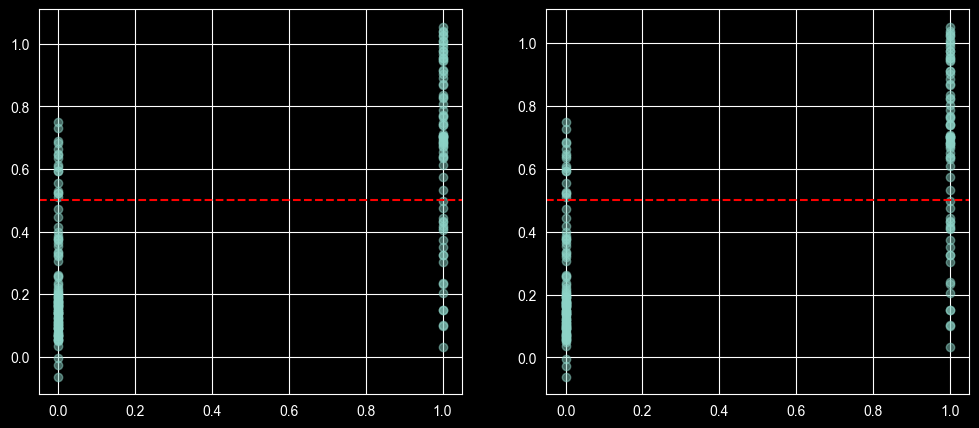

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred_lr, alpha=0.5)
axes[0].axhline(0.5, color='r', linestyle='--')

axes[1].scatter(y_test, y_pred_ridge, alpha=0.5)
axes[1].axhline(0.5, color='r', linestyle='--')
plt.show()

In [145]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing(as_frame=True)
df = housing.frame
X = housing.data
y = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [147]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


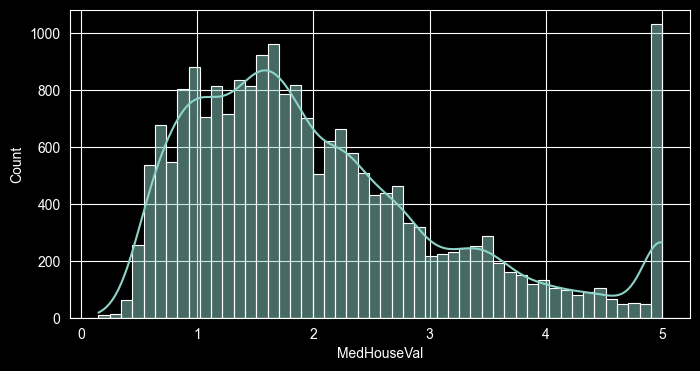

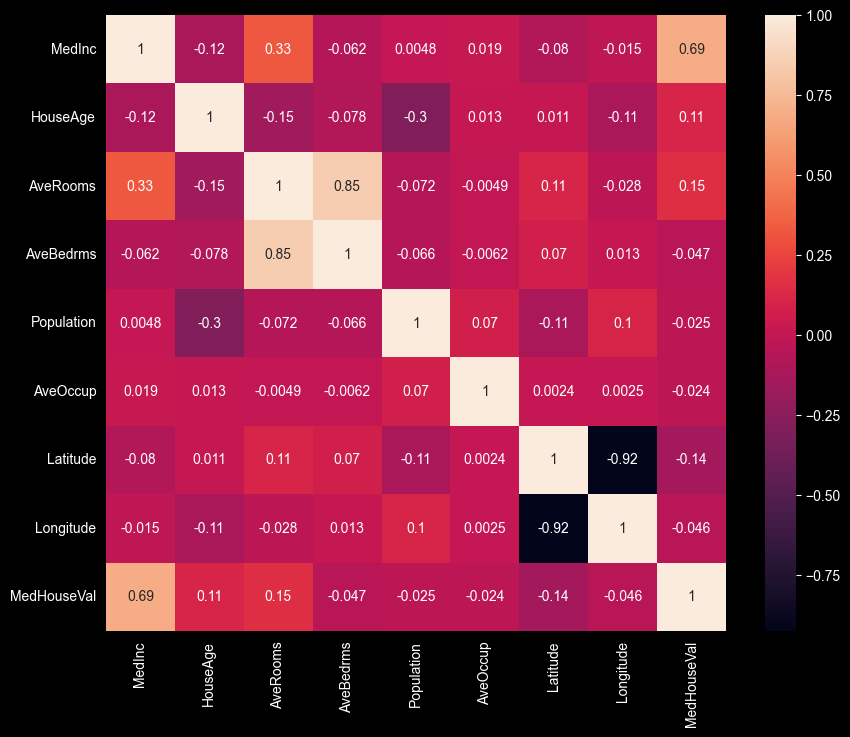

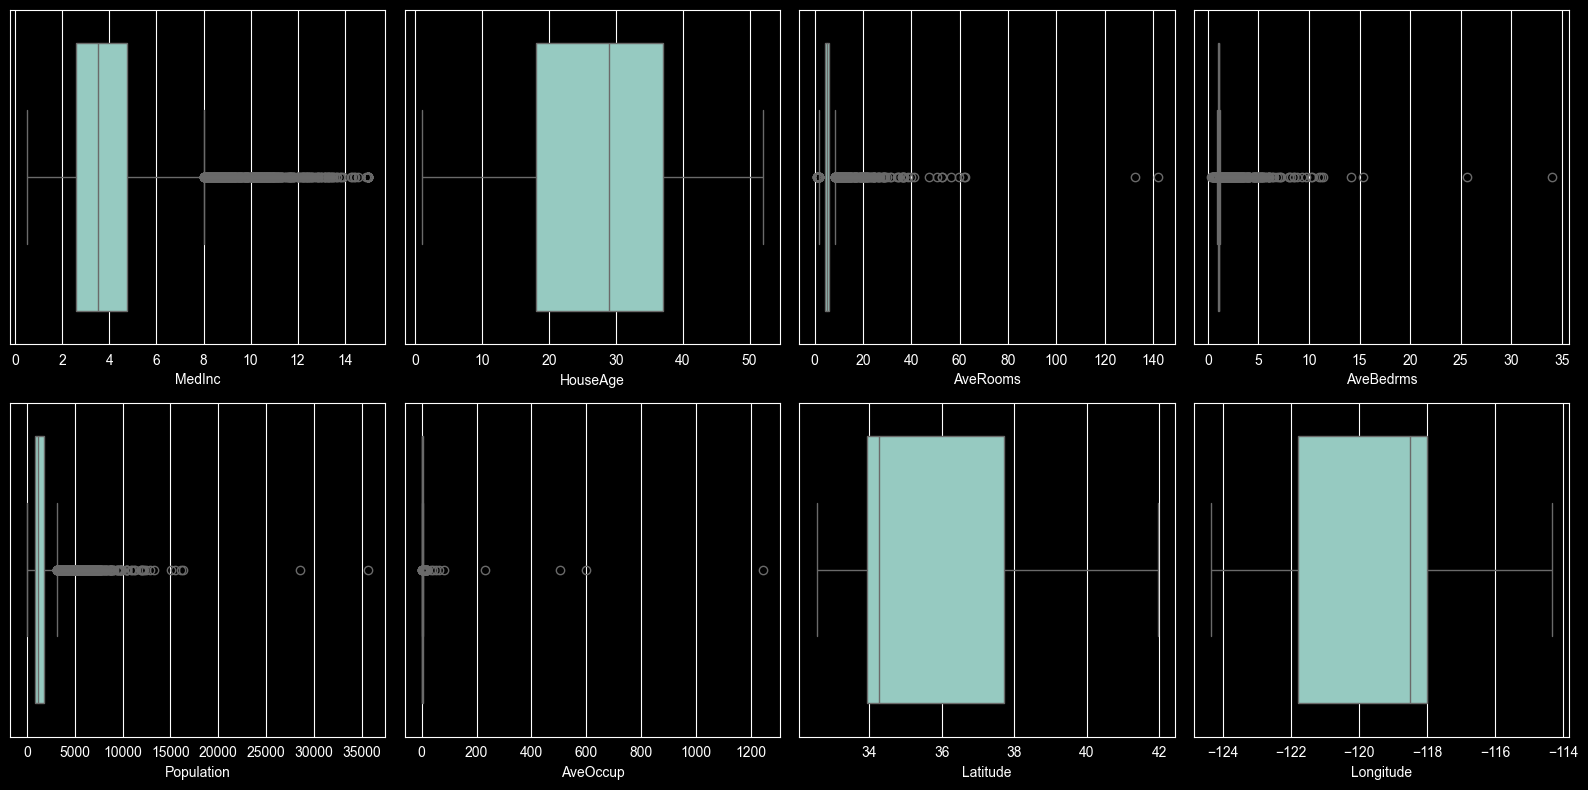

In [148]:
plt.figure(figsize=(8,4))
sns.histplot(y, bins=50, kde=True)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16,8))
for ax, col in zip(axes.flatten(), X.columns):
    sns.boxplot(x=df[col], ax=ax)
plt.tight_layout()
plt.show()

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression: RMSE = 0.7456, R² = 0.5758


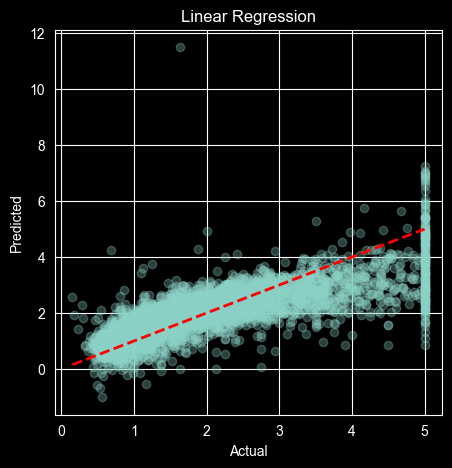

Random Forest: RMSE = 0.5049, R² = 0.8054


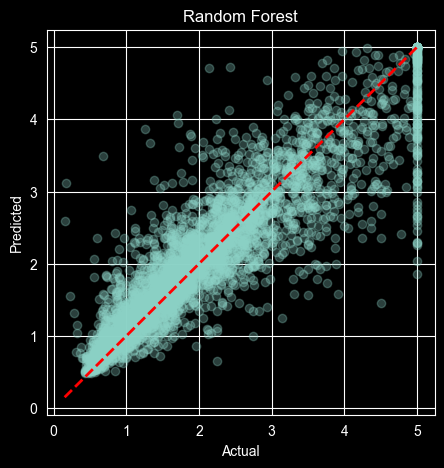

Gradient Boosting: RMSE = 0.5422, R² = 0.7756


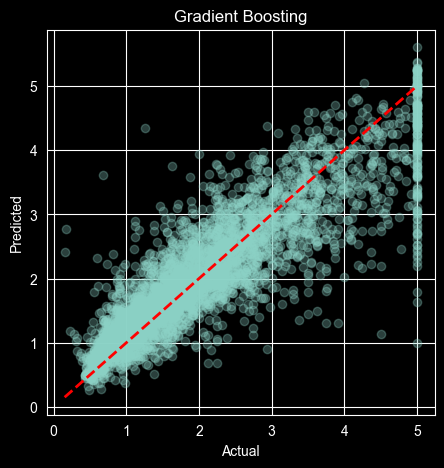

SVR: RMSE = 0.5975, R² = 0.7276


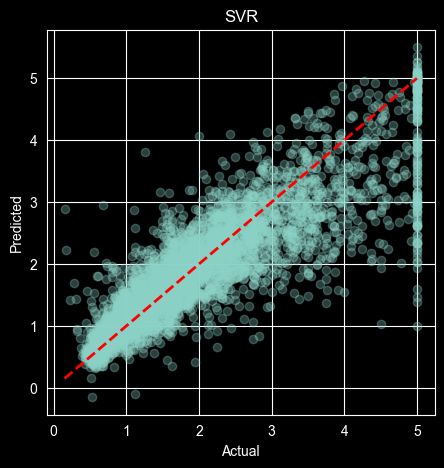

KNN: RMSE = 0.6576, R² = 0.6700


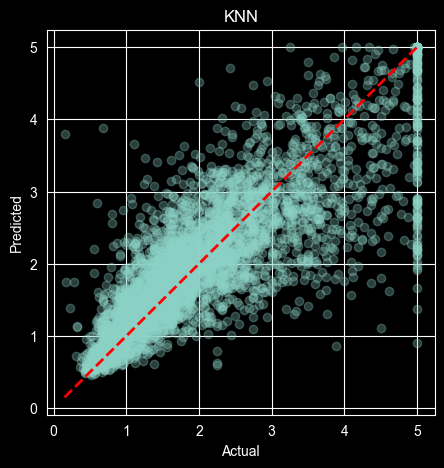

In [150]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=21),
    'Gradient Boosting': GradientBoostingRegressor(random_state=21),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

    plt.figure(figsize=(5,5))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name}')
    plt.show()

In [151]:
from sklearn.model_selection import GridSearchCV

# --- RandomForest ---
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid_rf, cv=3, scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)
print('RF best params:', grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

# --- GradientBoosting ---
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       param_grid_gb, cv=3, scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)
grid_gb.fit(X_train_scaled, y_train)
print('GB best params:', grid_gb.best_params_)
best_gb = grid_gb.best_estimator_

# --- SVR ---
param_grid_svr = {
    'kernel': ['rbf'],
    'C': [0.5, 1, 2],
    'gamma': ['scale', 'auto']
}
grid_svr = GridSearchCV(SVR(),
                        param_grid_svr, cv=3, scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=1)
grid_svr.fit(X_train_scaled, y_train)
print('SVR best params:', grid_svr.best_params_)
best_svr = grid_svr.best_estimator_

# --- KNN ---
param_grid_knn = {
    'n_neighbors': [5, 7, 9],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsRegressor(),
                        param_grid_knn, cv=3, scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=1)
grid_knn.fit(X_train_scaled, y_train)
print('KNN best params:', grid_knn.best_params_)
best_knn = grid_knn.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits
RF best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Fitting 3 folds for each of 8 candidates, totalling 24 fits
GB best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Fitting 3 folds for each of 6 candidates, totalling 18 fits
SVR best params: {'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Fitting 3 folds for each of 6 candidates, totalling 18 fits
KNN best params: {'n_neighbors': 9, 'weights': 'distance'}


In [152]:
from sklearn.ensemble import VotingRegressor

voting_reg = VotingRegressor([
    ('rf', best_rf),
    ('gb', best_gb),
    ('svr', best_svr),
    ('knn', best_knn),
    ('lr', LinearRegression())
])
voting_reg.fit(X_train_scaled, y_train)
y_pred_vote = voting_reg.predict(X_test_scaled)

rmse_vote = np.sqrt(mean_squared_error(y_test, y_pred_vote))
rmse_vote

np.float64(0.5405431945561228)

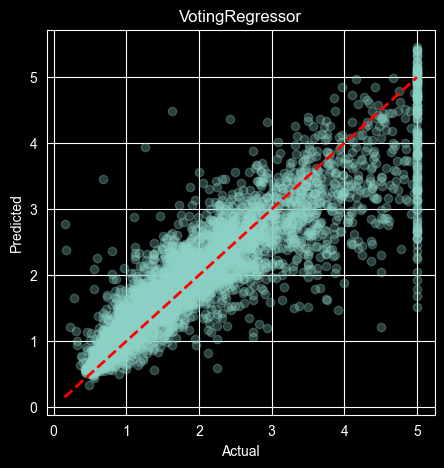

In [153]:

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_vote, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('VotingRegressor')
plt.show()